### A1

In [70]:
# Imports

from datasets import load_dataset
import pandas as pd
import re
from bs4 import BeautifulSoup
from IPython.display import display
import requests
import logging
from urllib.parse import urlparse, parse_qs,urljoin

In [71]:
# 1. Φόρτωση του GreekLegalSum

dataset = load_dataset("DominusTea/GreekLegalSum", split="train")

In [72]:
# 2. Μετατροπή σε pandas DataFrame

df_ref = dataset.to_pandas()

In [73]:
# 3. Συνάρτηση εξαγωγής έτους από το ελεύθερο κείμενο

def extract_year(text):
    m = re.search(r"Αριθμός\s+\d+/(\d{4})", text)
    return int(m.group(1)) if m else None
df_ref['decision_year'] = df_ref['text'].apply(extract_year)
print("Reference years:", sorted(df_ref['decision_year'].dropna().unique()))

Reference years: [1995.0, 1999.0, 2000.0, 2001.0, 2002.0, 2003.0, 2004.0, 2005.0, 2006.0, 2007.0, 2008.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2014.0, 2015.0, 2016.0, 2017.0, 2018.0]


In [74]:
# 4. Ορισμός του schema στόχου για τον scraper

target_cols = [
    'decision_number','decision_year',
    'section_type','section_number',
    'court_intro','hearing_date',
    'publication_date',
    'judges','skefthike','gia_tous_logous',
    'penal_code_articles','penal_proc_articles',
    'civil_code_articles','civil_proc_code_articles',
    'url'
]

### A2

In [75]:
# shared HTTP client
session = requests.Session()
session.headers.update({"User-Agent": "Mozilla/5.0"})

# ρύθμιση logging
logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")

In [76]:
# Helper 1 : get_soup

def get_soup(url, timeout=10):
    """
    Κατεβάζει την `url`, θέτει encoding σε **windows-1253** και επιστρέφει
    `BeautifulSoup` αντικείμενο.  Αν προκύψει σφάλμα δικτύου ή HTTP 4xx/5xx,
    γράφει warning και επιστρέφει ``None`` ώστε το caller να το παρακάμψει.

    Parameters
    ----------
    url : str
        Πλήρες URL προς λήψη.
    timeout : int, default 10
        Timeout σε δευτερόλεπτα.

    Returns
    -------
    BeautifulSoup | None
        Το DOM της σελίδας ή `None` σε σφάλμα.
    """
    
    try:
        r = session.get(url, timeout=timeout)
        r.encoding = 'windows-1253'  # force Greek legacy codepage
        r.raise_for_status()
        return BeautifulSoup(r.text, 'html.parser')
    except Exception as e:
        logging.warning(f"Couldn’t fetch {url}: {e}")
        return None

In [77]:
# Helper 2 : get_all_2024_links

def get_all_2024_links():
    """
    Επιστρέφει λίστα από dictionaries με βασικά meta-δεδομένα και URL για όλες
    τις Πολιτικές & Ποινικές αποφάσεις του 2024.

    Κάνει POST στο `apofaseis_result.asp`, φιλτράρει τα links, αναλύει το
    querystring για `section_type` & `section_number`, κατασκευάζει το τελικό
    detail URL και αφαιρεί διπλοεγγραφές.

    Returns
    -------
    list[dict]
        Κάθε dict περιέχει: decision_number, decision_year, section_type,
        section_number, url.
    """

    form_url = "https://areiospagos.gr/nomologia/apofaseis_result.asp?S=1"
    payload = {
        "X_TMHMA": "6","X_SUB_TMHMA": "1",
        "X_TELESTIS_number": "1","x_number": "",
        "X_TELESTIS_ETOS": "1","x_ETOS": "2024",
        "submit_krit": "Αναζήτηση"
    }

    resp = session.post(form_url, data=payload, timeout=10)
    resp.encoding = 'windows-1253'
    soup = BeautifulSoup(resp.text, 'html.parser')

    results = []
    # βρες όλους τους συνδέσμους προς apofaseis_DISPLAY
    for a in soup.find_all("a", href=re.compile(r"apofaseis_DISPLAY", re.IGNORECASE)):
        txt = a.get_text(strip=True)
        if not re.match(r"^\d+\s*/\s*2024$", txt): continue # όχι 2024

        href = a['href']
        qs   = parse_qs(urlparse(href).query)
        info = qs.get("info", [""])[0].upper()
        
        if "ΠΟΛΙΤΙΚΕΣ" not in info and "ΠΟΙΝΙΚΕΣ" not in info:
            continue # ψάχνω μόνο πολιτικές/ποινικές

        num, yr = [p.strip() for p in txt.split("/")]

        # detail URL = σταθερό path + cd + apof
        cd       = qs.get("cd", [""])[0]
        apof     = f"{num}_{yr}"
        detail_url = (
            "https://areiospagos.gr/nomologia/apofaseis_DISPLAY.asp"
            f"?cd={cd}&apof={apof}"
        )

        # εξαγωγή τύπου & κωδικού τμήματος
        sect_type = sect_num = None
        if "," in info:
            p1,p2 = [x.strip() for x in info.split(",",1)]
            sect_num, sect_type = p1, p2
        elif "-" in info:
            st,sn = [x.strip() for x in info.split("-",1)]
            sect_type, sect_num = st, sn
        else:
            sect_type = info

        results.append({
            "decision_number": num,
            "decision_year":   yr,
            "section_type":    sect_type,
            "section_number":  sect_num,
            "url":             detail_url
        })

   
    # dedup
    unique, seen = [], set()
    for r in results:
        if r["url"] not in seen:
            seen.add(r["url"])
            unique.append(r)

    logging.info(f"Found {len(unique)} unique 2024 decision URLs.")
    return unique


In [78]:
# Helper 3 : extract_articles

def extract_articles(text: str, codes: list[str]) -> list[str]:
    """
    Επιστρέφει λίστα μοναδικών παραπομπών σε άρθρα για τους δοσμένους κώδικες.

    1.  Διορθώνει σύνηθες λατινικό “K” → ελληνικό «Κ».
    2.  Αναζητά παραπομπές:
        * παρενθετικές ``(80, 81 ΚΠΔ)`` ή ``(ΚΠολΔ 68)`` και
        * inline ``άρθρο 361 ΠΚ``.
    3.  Επιστρέφει ομοιόμορφα strings «άρθρο <N>» ή «άρθρο <N> παρ.<M>».

    Parameters
    ----------
    text : str
        Ολόκληρο κείμενο απόφασης.
    codes : list[str]
        Λίστα ακρωνυμίων ή πλήρων ονομάτων κωδίκων (π.χ. ['ΠΚ', 'Ποινικού Κώδικα']).

    Returns
    -------
    list[str]
        Μοναδική, διατηρημένης σειράς λίστα παραπομπών.
    """

    code_pat = "|".join(map(re.escape, codes))

    # κανονικοποίηση K→Κ
    text = text.replace('KΠολΔ', 'ΚΠολΔ').replace('KΠοινΔ', 'ΚΠοινΔ')

    # κατασκεύασε pattern που πιάνει και λατινικό και ελληνικό Κ
    code_patterns = []
    for code in codes:
        if code.startswith('Κ'):
            latin_alt = 'K' + code[1:]
            code_patterns += [re.escape(code), re.escape(latin_alt)]
        else:
            code_patterns.append(re.escape(code))
    code_pat = r"|".join(code_patterns)


    # ------------- regex παρενθέσεων & inline -----------------
    list_re = re.compile(rf"""
        \(\s*
        (?:(
            \d+(?:\s*παρ\.\s*\d+)?      
            (?:\s*(?:,|;|και|-)\s*\d+(?:\s*παρ\.\s*\d+)?)*
        )\s*(?:{code_pat})
        |
        (?:(?:{code_pat})\s*)
        (
            \d+(?:\s*παρ\.\s*\d+)?      
            (?:\s*(?:,|;|και|-)\s*\d+(?:\s*παρ\.\s*\d+)?)*
        )
        )
        [^)]*\)
    """, flags=re.IGNORECASE | re.VERBOSE)

    inline_re = re.compile(rf"""
        (?:άρθρου|άρθρο|άρθρα|άρθ\.?|αρθ)\s*
        (\d+(?:\s*παρ\.\s*\d+)?(?:\s*(?:,|;|και|-)\s*\d+(?:\s*παρ\.\s*\d+)?)* )
        (?=[\s\S]{{0,50}}(?:{code_pat}))
    """, flags=re.IGNORECASE | re.VERBOSE)


    def _scan_segment(seg: str) -> list[str]:
        """Εσωτερικό helper που συλλέγει & κανονικοποιεί matches."""

        raw = []
        # παρενθετικές
        for m in list_re.finditer(seg):
            nums = m.group(1) or m.group(2)
            for part in re.split(r"\s*(?:,|;|και|-)\s*", nums):
                part = part.strip()
                if not part:
                    continue
                m_full = re.match(r"^(\d+)\s*παρ\.\s*(\d+)$", part, re.IGNORECASE)
                if m_full:
                    art, par = m_full.groups()
                    raw.append(f"άρθρο {art} παρ.{par}")
                elif part.isdigit():
                    raw.append(f"άρθρο {part}")
        
        # inline «άρθρο …»
        for m in inline_re.finditer(seg):
            nums = m.group(1)
            last = None
            for part in re.split(r"\s*(?:,|;|και|-)\s*", nums):
                part = part.strip()
                if not part:
                    continue
                m_full = re.match(r"^(\d+)\s*παρ\.\s*(\d+)$", part, re.IGNORECASE)
                if m_full:
                    art, par = m_full.groups()
                    raw.append(f"άρθρο {art} παρ.{par}")
                    last = art
                elif part.isdigit():
                    if last:
                        raw.append(f"άρθρο {last} παρ.{part}")
                    else:
                        raw.append(f"άρθρο {part}")
                        last = part
        
        # μοναδικοποίηση
        seen = set()
        out = []
        for r in raw:
            if r not in seen:
                seen.add(r)
                out.append(r)
        return out

    # προτεραιότητα στο σκεπτικό
    start, end = text.find("ΣΚΕΦΘΗΚΕ"), text.find("ΓΙΑ ΤΟΥΣ")
    core = text[start:end] if start != -1 and end != -1 else text
    found = _scan_segment(core)
    return found or _scan_segment(text)


In [79]:
# Helper 4 : parse_decision_page

def parse_decision_page(link):
    """
    Παίρνει ένα dict (link) από το get_all_2024_links και επιστρέφει πλήρες
    record, συμπληρώνοντας όλα τα πεδία του `target_cols`.

    Επιστρέφει αρχικά κενά values (None / []) και γεμίζει τα εξής:
      * court_intro           : γραμμή μετά το banner «ΤΟ ΔΙΚΑΣΤΗΡΙΟ …»
      * decision_number/year  : από <title> ή fallback
      * hearing_date          : regex «Συνήλθε … στις»
      * publication_date      : regex «Δημοσιεύθηκε/Εκδόθηκε … στις»
      * judges                : regex «Συγκροτήθηκε από …»
      * skefthike             : block «ΣΚΕΦΘΗΚΕ …» μέχρι «ΓΙΑ ΤΟΥΣ»
      * gia_tous_logous       : block «ΓΙΑ ΤΟΥΣ ΛΟΓΟΥΣ ΑΥΤΟΥΣ» μέχρι πριν δημοσίευση
      * *_articles            : λίστες άρθρων μέσω extract_articles
    """
    
    data = {c: None for c in target_cols}
    data.update({
        'decision_number': link['decision_number'],
        'decision_year':   link['decision_year'],
        'section_type':    link['section_type'],
        'section_number':  link['section_number'],
        'url':             link['url']
    })

    soup = get_soup(data['url'])
    if not soup or soup.find(['iframe','embed']):
        return data   # skip non-HTML

    # crude text dump
    raw = soup.get_text('\n')

    # ――― court_intro ―――
    norm = re.sub(
        r"ΤΟ\s+ΔΙΚΑΣΤΗ\s+ΡΙΟ",
        "ΤΟ ΔΙΚΑΣΤΗΡΙΟ",
        raw,
        flags=re.IGNORECASE
    )
    m_intro = re.search(
        r"ΤΟ\s+ΔΙΚΑΣΤΗΡΙΟ\s+ΤΟΥ\s+ΑΡΕΙΟΥ\s+ΠΑΓΟΥ\s*\n\s*(.+)",
        norm,
        flags=re.IGNORECASE
    )
    if m_intro:
        data['court_intro'] = m_intro.group(1).strip()

    text = raw

    sect = (data.get('section_type') or "").upper()

    # header: αριθμός / έτος
    for tag in soup.find_all(['p','h1','h2','h3','title']):
        t = tag.get_text(' ', strip=True)
        m = re.search(r"(\d+)\s*/\s*(\d{4})", t)
        if m:
            data['decision_number'], data['decision_year'] = m.group(1), m.group(2)
            parts = re.split(r"\s–\s|\s-\s", t, 1)
            if len(parts)>1 and not data.get('court_intro'):
                data['court_intro'] = parts[1].strip()
            break

    # hearing_date
    md = re.search(r"Συνήλθε[\s\S]*?στις\s+(\d{1,2}\s+\S+\s+\d{4})",
                   text, re.IGNORECASE)
    if md:
        data['hearing_date'] = md.group(1).strip()

    # publication_date
    m_pub = re.search(
        r"""
        (?:Δημοσιεύθηκε|ΔΗΜΟΣΙΕΥΘΗΚΕ|Εκδόθηκε)  # one of the keywords
        [\s\S]{0,200}?                          # anything up to the date phrase
        (?:στις|την)\s+                        # 'στις' or 'την'
        (\d{1,2}(?:η)?\s+\S+\s+\d{4})           # capture '1η Οκτωβρίου 2024' or '14 Οκτωβρίου 2024'
        """,
        text,
        re.IGNORECASE | re.VERBOSE
    )
    if m_pub:
        data['publication_date'] = m_pub.group(1).strip()


    # judges
    mj = re.search(
        r"""Συγκροτήθηκε\s+από\s+
           (?:
             τους\s+Δικαστές |
             τον\s+Πρόεδρο(?:\s+και\s+τους\s+Δικαστές)?
           )
           \s*[:\-]?\s*
           ([\s\S]+?)(?:Αρεοπαγίτες|\n|$)
        """,
        text, re.IGNORECASE | re.VERBOSE
    )
    if mj:
        raw = mj.group(1)
        names = [n.strip(" ,;") for n in re.split(r"[;,]", raw) if n.strip()]
        data['judges'] = names
        
    # skefthike block
    text = re.sub(r"ΣΚΕΦΤΗΚΕ", "ΣΚΕΦΘΗΚΕ", text, flags=re.IGNORECASE)
    sk = re.search(
        r"((?:ΣΚΕΦΘΗΚΕ|ΣΚΕΦΤΗΚΕ)[\s\S]+?)(?=\n(?:ΓΙΑ\s+ΤΟΥΣ|ΔΙΑΤΑΓΗ|ΑΠΟΦΑΣΗ)\b)",
        text, re.IGNORECASE
    )
    if sk:
        data['skefthike'] = sk.group(1).strip()

    # gia_tous_logous block
    gl = re.search(
        r"(ΓΙΑ\s+ΤΟΥΣ\s+ΛΟΓΟΥΣ[\s\S]+?)(?=\n(?:ΑΠΟΦΑΣΗ|ΔΙΑΤΑΓΗ|$))",
        text, re.IGNORECASE
    )
    if gl:
        data['gia_tous_logous'] = gl.group(1).strip()

    # άρθρα κωδίκων
    if 'ΠΟΙΝ' in sect:
        data['penal_code_articles']    = extract_articles(text, ['ΠΚ', 'Ποινικού Κώδικα'])
        data['penal_proc_articles']    = extract_articles(
            text,
            ['ΚΠΔ', 'ΚΠοινΔ', 'Ποινικής Δικονομίας']
        )
    if 'ΠΟΛΙΤ' in sect:
        data['civil_code_articles']     = extract_articles(text, ['ΑΚ'])
        data['civil_proc_code_articles']= extract_articles(text, ['ΚΠολΔ'])
    return data

In [80]:
links = get_all_2024_links()

INFO: Found 2402 unique 2024 decision URLs.


In [81]:
records = [parse_decision_page(l) for l in links]

In [82]:
df = pd.DataFrame.from_records(records)

with open("areios_pagos_2024.csv", 
          "w", 
          encoding="utf-8-sig",   # UTF-8 with BOM
          newline="") as f:
    df.to_csv(f, index=False)

logging.info("CSV written to areios_pagos_2024.csv")


INFO: CSV written to areios_pagos_2024.csv


In [83]:
# Helper : display csv quickly in notebook

def display_csv_as_table(csv_path):
    """
    Διαβάζει CSV από δίσκο και το εμφανίζει ως DataFrame (IPython.display).

    Parameters
    ----------
    csv_path : str
        Διαδρομή αρχείου CSV.
    """

    df_csv = pd.read_csv(csv_path)
    display(df_csv)

### A3

In [84]:
display_csv_as_table("areios_pagos_2024.csv")

,decision_number,decision_year,section_type,section_number,court_intro,hearing_date,publication_date,judges,skefthike,gia_tous_logous,penal_code_articles,penal_proc_articles,civil_code_articles,civil_proc_code_articles,url
0,11,2024,ΠΟΛΙΤΙΚΕΣ,Β1,Β1' Πολιτικό Τμήμα,30 Ιουνίου 2022,5 Ιανουαρίου 2024,"['Λουκά Μόρφη', 'Αντιπρόεδρο του Αρείου Πάγου'...",ΣΚΕΦΘΗΚΕ ΣΥΜΦΩΝΑ ΜΕ ΤΟ ΝΟΜΟ\n\nΑπό τη διάταξη ...,ΓΙΑ ΤΟΥΣ ΛΟΓΟΥΣ ΑΥΤΟΥΣ \n\nΑπορρίπτει την από ...,NaN,NaN,['άρθρο 361'],"['άρθρο 80', 'άρθρο 68', 'άρθρο 622', 'άρθρο 6...",https://areiospagos.gr/nomologia/apofaseis_DIS...
1,12,2024,ΠΟΛΙΤΙΚΕΣ,Β1,Β1' Πολιτικό Τμήμα,30 Ιουνίου 2022,5 Ιανουαρίου 2024,"['Λουκά Μόρφη', 'Αντιπρόεδρο του Αρείου Πάγου'...",ΣΚΕΦΘΗΚΕ ΣΥΜΦΩΝΑ ΜΕ ΤΟ ΝΟΜΟ\n\nΥπόκειται προς ...,ΓΙΑ ΤΟΥΣ ΛΟΓΟΥΣ ΑΥΤΟΥΣ \n\nΑπορρίπτει την από ...,NaN,NaN,['άρθρο 932'],"['άρθρο 564 παρ.1', 'άρθρο 552', 'άρθρο 552 πα...",https://areiospagos.gr/nomologia/apofaseis_DIS...
2,13,2024,ΠΟΛΙΤΙΚΕΣ,Β1,Β1' Πολιτικό Τμήμα,13 Νοεμβρίου 2023,5 Ιανουαρίου 2024,"['Ιωάννα Μαργέλλου-Μπουλταδάκη', 'Προεδρεύουσα...",ΣΚΕΦΘΗΚΕ ΣΥΜΦΩΝΑ ΜΕ ΤΟ ΝΟΜΟ\n\nΜε την από 16 Ι...,ΓΙΑ ΤΟΥΣ ΛΟΓΟΥΣ ΑΥΤΟΥΣ \n\nΑπορρίπτει την από ...,NaN,NaN,"['άρθρο 38', 'άρθρο 176', 'άρθρο 176 παρ.183',...","['άρθρο 552', 'άρθρο 552 παρ.553', 'άρθρο 552 ...",https://areiospagos.gr/nomologia/apofaseis_DIS...
3,14,2024,ΠΟΛΙΤΙΚΕΣ,Β1,Β1' Πολιτικό Τμήμα,13 Νοεμβρίου 2023,5 Ιανουαρίου 2023,"['Ιωάννα Μαργέλλου-Μπουλταδάκη', 'Προεδρεύουσα...",ΣΚΕΦΘΗΚΕ ΣΥΜΦΩΝΑ ΜΕ ΤΟ ΝΟΜΟ\n\nΜε την από 2 Νο...,ΓΙΑ ΤΟΥΣ ΛΟΓΟΥΣ ΑΥΤΟΥΣ \n\nΑπορρίπτει την από ...,NaN,NaN,"['άρθρο 8 παρ.1', 'άρθρο 656']","['άρθρο 552', 'άρθρο 552 παρ.553', 'άρθρο 552 ...",https://areiospagos.gr/nomologia/apofaseis_DIS...
4,31,2024,ΠΟΛΙΤΙΚΕΣ,Β1,Β1' Πολιτικό Τμήμα,5 Δεκεμβρίου 2023,9 Ιανουαρίου 2024,"['Δήμητρα Ζώη', 'Αντιπρόεδρο του Αρείου Πάγου'...",ΣΚΕΦΘΗΚΕ ΣΥΜΦΩΝΑ ΜΕ ΤΟ ΝΟΜΟ\n\nΜε τη διάταξη τ...,ΓΙΑ ΤΟΥΣ ΛΟΓΟΥΣ ΑΥΤΟΥΣ Συνεκδικάζει την από 15...,NaN,NaN,"['άρθρο 577 παρ.3', 'άρθρο 904', 'άρθρο 14', '...","['άρθρο 576 παρ.1', 'άρθρο 143 παρ.1', 'άρθρο ...",https://areiospagos.gr/nomologia/apofaseis_DIS...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2397,1096,2024,ΠΟΙΝΙΚΕΣ,Β ΠΟΙΝ. ΔΙΑΚ.,Β' Ποινικό Τμήμα Διακοπών (Σε Συμβούλιο),3 Σεπτεμβρίου 2024,13 Σεπτεμβρίου 2024,"['Απόστολο Φωτόπουλο', 'Προεδρεύοντα Αρεοπαγίτ...","ΣΚΕΦΘΗΚΕ ΣΥΜΦΩΝΑ ΜΕ ΤΟ ΝΟΜΟ\n\n\n\nΕισάγεται, ...",ΓΙΑ ΤΟΥΣ ΛΟΓΟΥΣ ΑΥΤΟΥΣ \n\n\n\nΑνακαλεί την υπ...,['άρθρο 259'],"['άρθρο 136 παρ.2', 'άρθρο 135', 'άρθρο 122', ...",NaN,NaN,https://areiospagos.gr/nomologia/apofaseis_DIS...
2398,1157,2024,ΠΟΙΝΙΚΕΣ,Β ΠΟΙΝ. ΔΙΑΚ.,B' ΠΟΙΝΙΚΟ ΤΜΗΜΑ ΔΙΑΚΟΠΩΝ,3 Σεπτεμβρίου 2024,1η Οκτωβρίου 2024,"['Απόστολο Φωτόπουλο', 'Προεδρεύοντα Αρεοπαγίτ...",ΣΚΕΦΘΗΚΕ ΣΥΜΦΩΝΑ ΜΕ ΤΟ ΝΟΜΟ\n\n\n\nΜε την από ...,ΓΙΑ ΤΟΥΣ ΛΟΓΟΥΣ ΑΥΤΟΥΣ \n\n\n\nΑναιρεί στο σύν...,"['άρθρο 84', 'άρθρο 1', 'άρθρο 1 παρ.2', 'άρθρ...","['άρθρο 473 παρ.2', 'άρθρο 473 παρ.3', 'άρθρο ...",NaN,NaN,https://areiospagos.gr/nomologia/apofaseis_DIS...
2399,1158,2024,ΠΟΙΝΙΚΕΣ,Β ΠΟΙΝ. ΔΙΑΚ.,B' ΠΟΙΝΙΚΟ ΤΜΗΜΑ ΔΙΑΚΟΠΩΝ - ΣΕ ΣΥΜΒΟΥΛΙΟ,3 Σεπτεμβρίου 2024,1η Οκτωβρίου 2024,"['Απόστολο Φωτόπουλο', 'Προεδρεύοντα Αρεοπαγίτ...",ΣΚΕΦΘΗΚΕ ΣΥΜΦΩΝΑ ΜΕ ΤΟ ΝΟΜΟ\n\n\n\nΣύμφωνα με ...,ΓΙΑ ΤΟΥΣ ΛΟΓΟΥΣ ΑΥΤΟΥΣ \n\n\n\nΠροτείνω: \n\n\...,"['άρθρο 1', 'άρθρο 1 παρ.12', 'άρθρο 14 παρ.1'...","['άρθρο 30 παρ.2', 'άρθρο 30 παρ.4', 'άρθρο 13...",NaN,NaN,https://areiospagos.gr/nomologia/apofaseis_DIS...
2400,1160,2024,ΠΟΙΝΙΚΕΣ,Β ΠΟΙΝ. ΔΙΑΚ.,Β' Ποινικό Τμήμα Διακοπών,3 Σεπτεμβρίου 2024,1η Οκτωβρίου 2024,"['Απόστολο Φωτόπουλο', 'Προεδρεύοντα Αρεοπαγίτ...",ΣΚΕΦΘΗΚΕ ΣΥΜΦΩΝΑ ΜΕ ΤΟ ΝΟΜΟ\n\n\n\nΗ υπό κρίση...,ΓΙΑ ΤΟΥΣ ΛΟΓΟΥΣ ΑΥΤΟΥΣ \n\n\n\nΑΝΑΙΡΕΙ την υπ`...,"['άρθρο 224 παρ.1', 'άρθρο 224']","['άρθρο 474 παρ.1', 'άρθρο 4', 'άρθρο 510 παρ.1']",NaN,NaN,https://areiospagos.gr/nomologia/apofaseis_DIS...


In [85]:
# 0. Columns

print("Columns in GreekLegalSum:")
print(df_ref.columns.tolist())

Columns in GreekLegalSum:
['text', 'summary', 'case_category', 'case_tags', 'subset', 'decision_year']


In [87]:
df_ref["year"] = df_ref["text"].apply(extract_year)

In [ ]:
# δείγμα αποφάσεων 2018 για ανάλυση και σύγκριση

df_2018 = df_ref[df_ref['year'] == 2018]

In [90]:
display(df_2018.head(10))

,text,summary,case_category,case_tags,subset,decision_year,year
3,Αριθμός 1502/2018 \n\nΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ...,Αναίρεση Εισαγγελέα Αρείου Πάγου κατά αθωωτική...,Αβάσιμοι λόγοι,"Αναιρέσεως απόρριψη, Εισαγγελέας Αρείου Πάγου,...",2.0,2018.0,2018.0
4,Αριθμός 1501/2018 \n\nΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ...,Κατ' εξακολούθηση απάτη κατ' επάγγελμα και κατ...,Αβάσιμοι λόγοι,"Ακυρότητα απόλυτη, Αναιρέσεως απόρριψη, Απάτη,...",1.0,2018.0,2018.0
5,Αριθμός 1500/2018 \n\nΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ...,Άμεση συνέργεια σε καταδολίευση δανειστή. Λόγο...,Αβάσιμοι λόγοι,"Αναιρέσεως απόρριψη, Καταδολίευση δανειστών, Έ...",0.0,2018.0,2018.0
6,Αριθμός 1499/2018 \n\nΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ...,Αίτηση αναιρέσεως κατά αποφάσεως που απέρριψε ...,Αβάσιμοι λόγοι,"Αναιρέσεως απόρριψη, Έλλειψη ειδικής και εμπερ...",0.0,2018.0,2018.0
7,Αριθμός 1498/2018 \n\nΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ...,Συνεκδίκαση δύο αιτήσεων αναιρέσεως. Απιστία σ...,Συνεκδίκαση,"Αναιρέσεως απόρριψη, Συνεκδίκαση, Απιστία στην...",0.0,2018.0,2018.0
8,Αριθμός 1496/2018 \n\nΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ...,"Απόπειρα ανθρωποκτονίας, οπλοφορία, οπλοχρησία...",Ακροάσεως έλλειψη,"Αιτιολογίας ανεπάρκεια, Υπέρβαση εξουσίας, Ακρ...",0.0,2018.0,2018.0
9,Αριθμός 1495/2018 \n\nΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ...,Συκοφαντική δυσφήμηση. Αναίρεση κατηγορουμένου...,Αιτιολογίας ανεπάρκεια,"Αιτιολογίας ανεπάρκεια, Υπέρβαση εξουσίας, Δυσ...",2.0,2018.0,2018.0
10,Αριθμός 1494/2018 \n\nΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ...,Απάτη με ζημία άνω των 120.000 ευρώ. Λόγοι ανα...,Έξοδα,"Αναιρέσεως απόρριψη, Απάτη, Έλλειψη ειδικής κα...",0.0,2018.0,2018.0
11,Αριθμός 1493/2018 \n\nΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ...,Κατ' εξακολούθηση έκδοση ακάλυπτης επιταγής. Λ...,Ακυρότητα απόλυτη,"Ακυρότητα απόλυτη, Αναιρέσεως απόρριψη, Υπέρβα...",0.0,2018.0,2018.0
12,Αριθμός 1491/2018 \n\nΤΟ ΔΙΚΑΣΤΗΡΙΟ ΤΟΥ ΑΡΕΙΟΥ...,Μη εμπρόθεσμη καταβολή εργατικών αποδοχών (δεδ...,Έλλειψη ειδικής και εμπεριστατωμένης αιτιολογίας,"Αναιρέσεως λόγοι, Έλλειψη ειδικής και εμπεριστ...",0.0,2018.0,2018.0


### A4

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

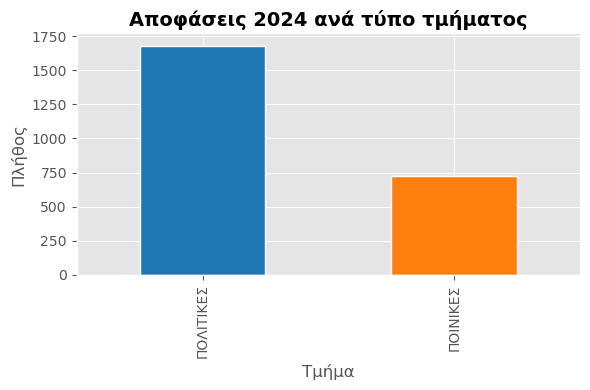

In [96]:
# -----------------------------------------------------------------------------
# Plot 1 – Πλήθος αποφάσεων 2024 ανά τύπο τμήματος
# -----------------------------------------------------------------------------
"""
Ερώτημα
-------
Ποιες αποφάσεις είναι περισσότερες το 2024, Πολιτικές ή Ποινικές;

Γιατί bar chart
---------------
• έχουμε δύο κατηγορίες, θέλω αθροιστικούς αριθμούς,  
• το ύψος της ράβδου διαβάζεται αμέσως, καμία γνωστική
  επιβάρυνση στον αναγνώστη.

Ερμηνεία
--------
Μία μπλε και μία πορτοκαλί ράβδος· η ψηλότερη δείχνει ποιος
κλάδος “παράγει” περισσότερες αποφάσεις.
"""

counts = df['section_type'].value_counts()

colour_map = {
    'ΠΟΙΝΙΚΕΣ': '#ff7f0e',   
    'ΠΟΛΙΤΙΚΕΣ': '#1f77b4'  
}
colors = [colour_map.get(idx, '#888888') for idx in counts.index]

plt.figure(figsize=(6,4))
counts.plot(
    kind='bar',
    color=colors,
    edgecolor='white',
    linewidth=1
)
plt.title('Αποφάσεις 2024 ανά τύπο τμήματος', fontsize=14, fontweight='bold')
plt.xlabel('Τμήμα', fontsize=12)
plt.ylabel('Πλήθος', fontsize=12)

for spine in ['top','right']:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

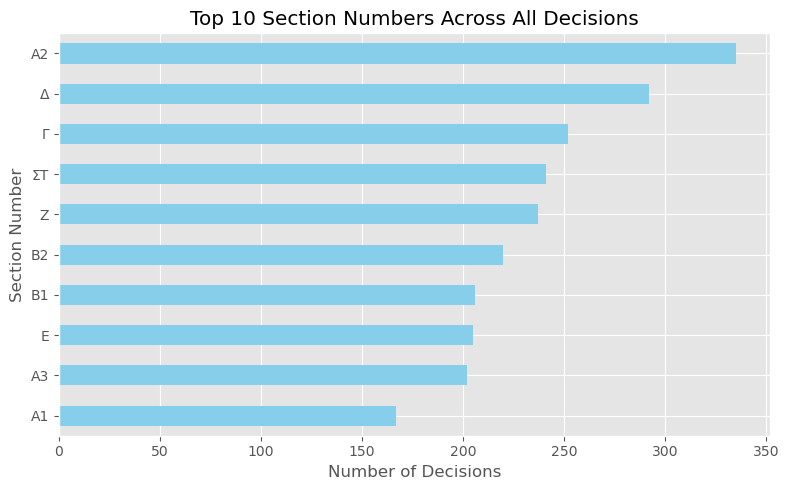

In [97]:
# -----------------------------------------------------------------------------
# Plot 2 – Top-10 section_number (συνολικά)
# -----------------------------------------------------------------------------
"""
Ερώτημα
-------
Ποια τμήματα (Β1, Γ2 κ.λπ.) εξέδωσαν τις περισσότερες αποφάσεις
ανεξάρτητα από κατηγορία;

Γιατί horizontal bar
--------------------
• πολλές κατηγορίες → χρειάζεται χώρο για labels,  
• ο άξονας x δείχνει πλήθος αποφάσεων – εύκολη σύγκριση.

Ερμηνεία
--------
Η μπάρα στο πάνω μέρος (ανεστραμμένος άξονας y) είναι το δημοφιλέστερο
τμήμα· οι υπόλοιπες ακολουθούν φθίνουσα.
"""

sec_counts = df['section_number'].value_counts().head(10)

plt.figure(figsize=(8, 5))
sec_counts.plot(kind='barh', color='skyblue')
plt.title('Top 10 Section Numbers Across All Decisions')
plt.xlabel('Number of Decisions')
plt.ylabel('Section Number')
plt.gca().invert_yaxis()   
plt.tight_layout()
plt.show()

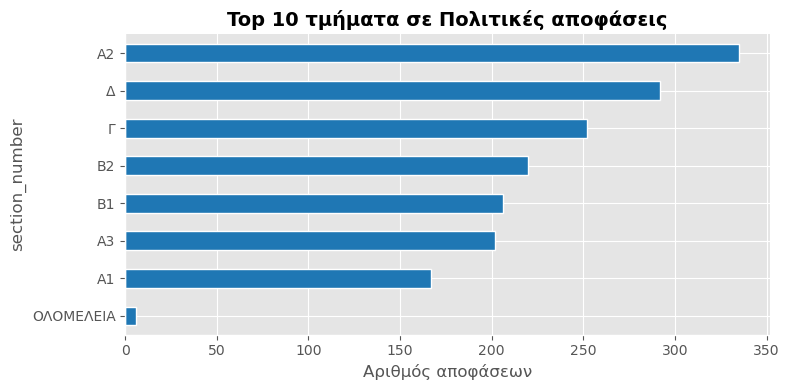

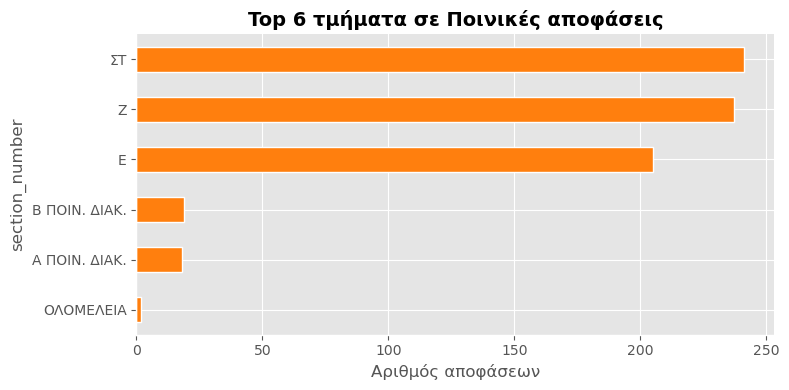

In [98]:
# -----------------------------------------------------------------------------
# Plot 3 – Top-10 Πολιτικών τμημάτων (μπλε)
# -----------------------------------------------------------------------------
"""
Ερώτημα
-------
Μόνο σε Πολιτικές αποφάσεις, ποια τμήματα εμφανίζονται συχνότερα;

Ερμηνεία
--------
Όσο πιο δεξιά η μπάρα, τόσο μεγαλύτερη η παραγωγή αποφάσεων
του συγκεκριμένου πολιτικού τμήματος.
"""

# -----------------------------------------------------------------------------
# Plot 4 – Top-6 Ποινικών τμημάτων (πορτοκαλί)
# -----------------------------------------------------------------------------
"""
Ερώτημα
-------
Στις Ποινικές, ποια είναι τα έξι τμήματα με την πιο υψηλή δραστηριότητα;

Ερμηνεία
--------
Η πιο μακριά πορτοκαλί μπάρα = τμήμα με τις περισσότερες
ποινικές αποφάσεις.
"""

pol_counts = (
    df[df['section_type'].str.contains('ΠΟΛΙΤ', na=False)]
      ['section_number']
      .value_counts()
      .head(10)
)

plt.figure(figsize=(8,4))
pol_counts.plot(
    kind='barh',
    color='#1f77b4',      
    edgecolor='white',
    linewidth=1
)
plt.title('Top 10 τμήματα σε Πολιτικές αποφάσεις', fontsize=14, fontweight='bold')
plt.xlabel('Αριθμός αποφάσεων', fontsize=12)
plt.gca().invert_yaxis()
for spine in ['top','right']:
    plt.gca().spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

crim_counts = (
    df[df['section_type'].str.contains('ΠΟΙΝ', na=False)]
      ['section_number']
      .value_counts()
      .head(6)
)

plt.figure(figsize=(8,4))
crim_counts.plot(
    kind='barh',
    color='#ff7f0e',     
    edgecolor='white',
    linewidth=1
)
plt.title('Top 6 τμήματα σε Ποινικές αποφάσεις', fontsize=14, fontweight='bold')
plt.xlabel('Αριθμός αποφάσεων', fontsize=12)
plt.gca().invert_yaxis()
for spine in ['top','right']:
    plt.gca().spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

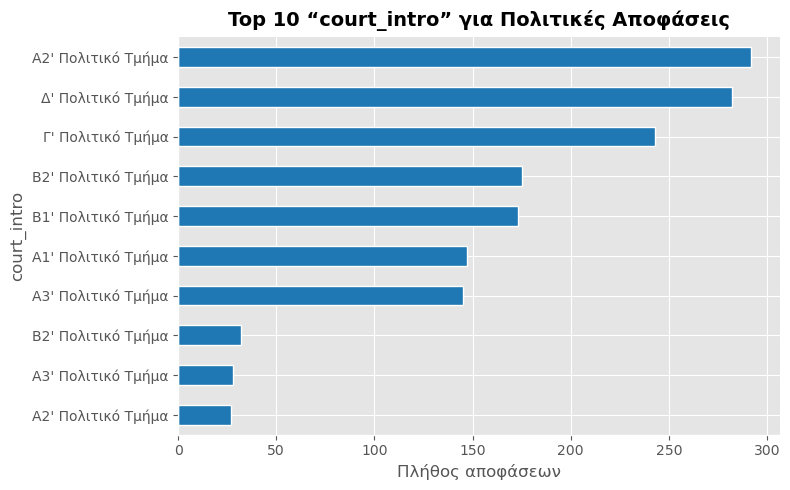

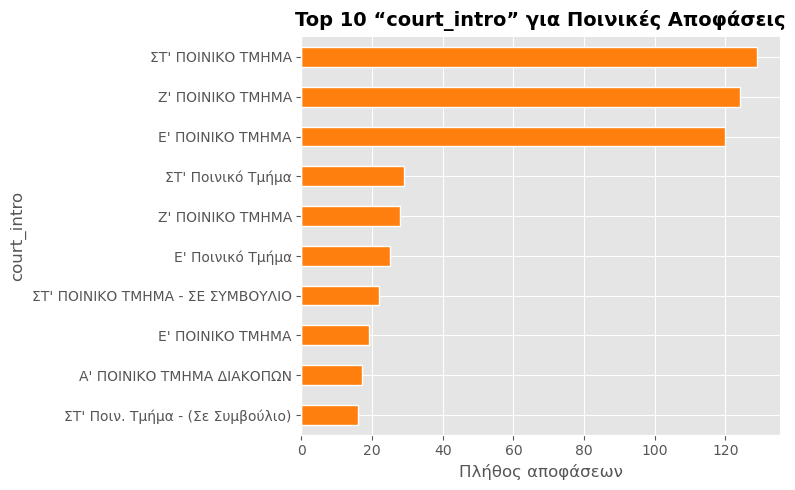

In [99]:
# -----------------------------------------------------------------------------
# Plot 5 – court_intro: top-10 για Πολιτικές
# -----------------------------------------------------------------------------
"""
Ερώτημα
-------
Ποια court_intro (π.χ. «Β1' Πολιτικό Τμήμα»)
εμφανίζονται συχνότερα στις Πολιτικές;

Ερμηνεία
--------
Οι bars δείχνουν πόσες φορές το κάθε intro συναντάται.
Χρήσιμο για να εντοπίσω ποια υπο-υπηρεσία του Αρείου Πάγου
χειρίζεται τα περισσότερα πολιτικά θέματα.
"""

# -----------------------------------------------------------------------------
# Plot 6 – court_intro: top-10 για Ποινικές
# -----------------------------------------------------------------------------
"""
Ερώτημα
-------
Το αντίστοιχο για Ποινικές: ποια tags court_intro πρωταγωνιστούν;

Ερμηνεία
--------
Μελετώντας τα 10 πρώτα βλέπω ποια ποινικά τμήματα
(π.χ. «Ε' Ποινικό Τμήμα») είναι πιο παραγωγικά το 2024.
"""

pol_counts = (
    df[df['section_type'].str.contains('ΠΟΛΙΤ', na=False)]
      ['court_intro']
      .value_counts()
      .head(10)
)
crim_counts = (
    df[df['section_type'].str.contains('ΠΟΙΝ', na=False)]
      ['court_intro']
      .value_counts()
      .head(10)
)

fig, ax = plt.subplots(figsize=(8, 5))
pol_counts.plot(
    kind='barh',
    color='#1f77b4',       
    edgecolor='white',
    linewidth=1,
    ax=ax
)
ax.set_title(
    'Top 10 “court_intro” για Πολιτικές Αποφάσεις',
    fontsize=14, fontweight='bold', pad=8
)
ax.set_xlabel('Πλήθος αποφάσεων', fontsize=12)
ax.invert_yaxis()
for spine in ['top','right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
crim_counts.plot(
    kind='barh',
    color='#ff7f0e',        
    edgecolor='white',
    linewidth=1,
    ax=ax
)
ax.set_title(
    'Top 10 “court_intro” για Ποινικές Αποφάσεις',
    fontsize=14, fontweight='bold', pad=8
)
ax.set_xlabel('Πλήθος αποφάσεων', fontsize=12)
ax.invert_yaxis()
for spine in ['top','right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

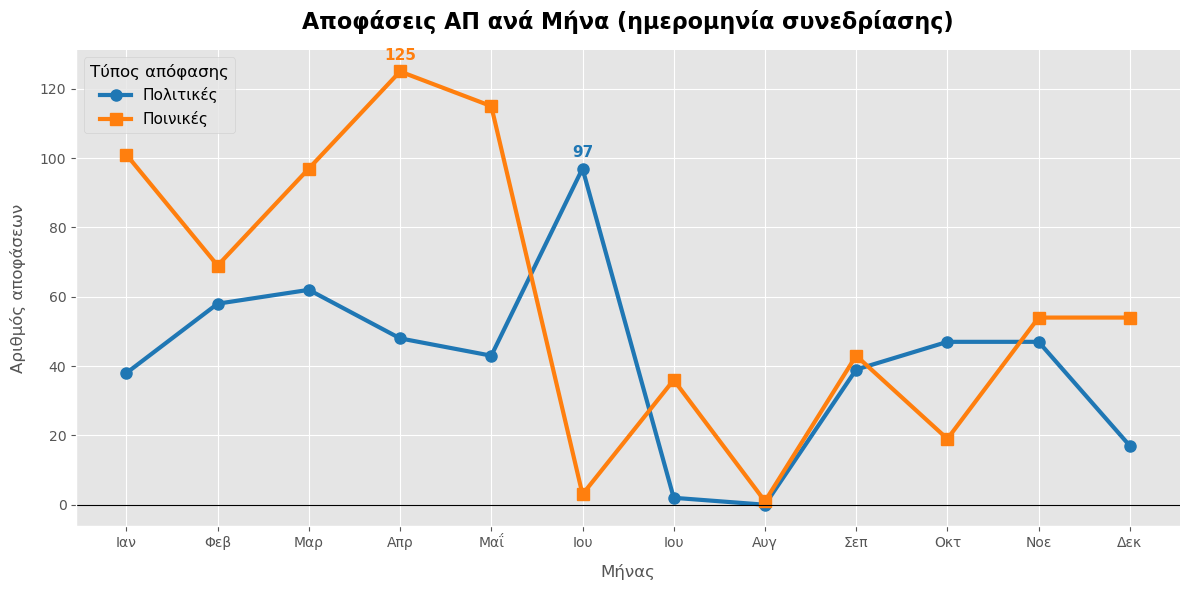

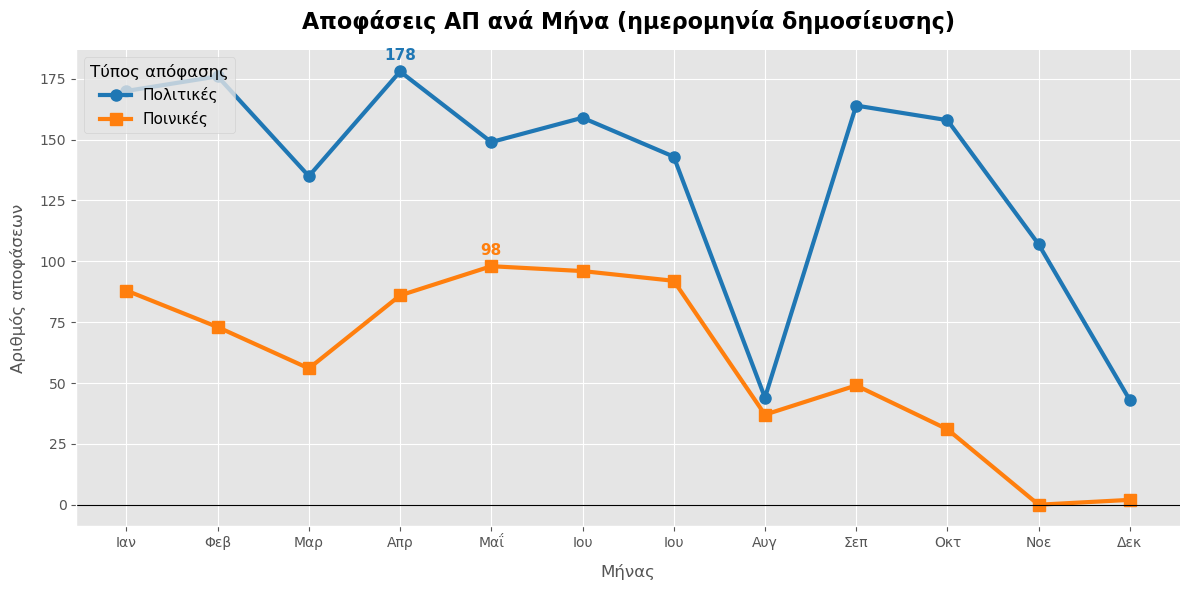

In [100]:
# -----------------------------------------------------------------------------
# Plot 7 – Χρονική κατανομή: συνεδριάσεις (hearing_date)
# -----------------------------------------------------------------------------
"""
Ερώτημα
-------
Ποιοι μήνες του 2024 είχαν τις περισσότερες συνεδριάσεις -
και πώς κατανέμονται ανά τύπο τμήματος (Πολιτικές vs Ποινικές);

Γιατί line plot
---------------
• Οι 12 μήνες είναι φυσική χρονολογική κλίμακα· η γραμμή δείχνει
  «κύματα» δραστηριότητας πολύ καλύτερα από στήλες.  
• Τα δύο χρώματα επιτρέπουν άμεση σύγκριση ανάμεσα στα τμήματα.

Ερμηνεία
--------
Η κορυφαία κορυφή δηλώνει τον “θερμότερο” μήνα· το label επάνω στην
κορυφή δείχνει ακριβώς πόσες συνεδριάσεις έγιναν.
Η απόσταση ανάμεσα στις δύο καμπύλες αποκαλύπτει ποιο τμήμα
κυριαρχεί κάθε μήνα.
"""

# -----------------------------------------------------------------------------
# Plot 8 – Χρονική κατανομή: δημοσιεύσεις (publication_date)
# -----------------------------------------------------------------------------
"""
Ερώτημα
-------
Πότε εκδίδονται τελικά οι αποφάσεις;  Υπάρχει «πλημμύρα»
δημοσιεύσεων σε συγκεκριμένο διάστημα του έτους;

Γιατί line plot
---------------
Όπως και στο hearing-plot· θέλουμε να δούμε εποχικότητα σε συνεχή άξονα.

Ερμηνεία
--------
Οι δύο γραμμές (μπλε / πορτοκαλί) δείχνουν αν οι κορυφώσεις
δημοσιεύσεων συμπίπτουν χρονικά με τις συνεδριάσεις ή
αν μεσολαβεί καθυστέρηση.
"""


month_order = [
    "Ιανουαρίου","Φεβρουαρίου","Μαρτίου","Απριλίου","Μαΐου","Ιουνίου",
    "Ιουλίου","Αυγούστου","Σεπτεμβρίου","Οκτωβρίου","Νοεμβρίου","Δεκεμβρίου"
]

for col, out in [('publication_date','pub_month'), ('hearing_date','hear_month')]:
    df[out] = (
        df[col]
          .fillna("")  
          .str.replace('η','', regex=False)  
          .str.split().str.get(1)            
    )
    df.loc[~df[out].isin(month_order), out] = pd.NA


pub_counts = (
    df
      .dropna(subset=['pub_month'])
      .groupby(['pub_month','section_type'])
      .size()
      .unstack(fill_value=0)
      .reindex(month_order)
)

hearing_counts = (
    df
      .dropna(subset=['hear_month'])
      .groupby(['hear_month','section_type'])
      .size()
      .unstack(fill_value=0)
      .reindex(month_order)
)


def plot_by_month(counts, title):
    plt.style.use('ggplot')
    fig, ax = plt.subplots(figsize=(12,6))

    ax.plot(
        counts.index, counts.get('ΠΟΛΙΤΙΚΕΣ',0),
        label='Πολιτικές', color='#1f77b4',
        linewidth=3, marker='o', markersize=8
    )
    ax.plot(
        counts.index, counts.get('ΠΟΙΝΙΚΕΣ',0),
        label='Ποινικές', color='#ff7f0e',
        linewidth=3, marker='s', markersize=8
    )

    for series, color in [('ΠΟΛΙΤΙΚΕΣ','#1f77b4'), ('ΠΟΙΝΙΚΕΣ','#ff7f0e')]:
        if series in counts:
            m = counts[series].idxmax()
            v = counts[series].max()
            ax.annotate(
                f"{v}",
                xy=(m, v),
                xytext=(0,8),
                textcoords='offset points',
                ha='center',
                color=color,
                fontsize=11,
                fontweight='bold'
            )

    ax.set_xticks(counts.index)
    ax.set_xticklabels([m[:3] for m in counts.index], fontsize=10)
    ax.set_xlabel("Μήνας", fontsize=12, labelpad=10)
    ax.set_ylabel("Αριθμός αποφάσεων", fontsize=12, labelpad=10)
    ax.set_title(title, fontsize=16, fontweight='bold', pad=15)

    ax.legend(title="Τύπος απόφασης", loc='upper left', fontsize=11, title_fontsize=12)
    for spine in ['top','right']:
        ax.spines[spine].set_visible(False)
    ax.axhline(0, color='black', linewidth=0.8)

    plt.tight_layout()
    plt.show()

plot_by_month(hearing_counts, "Αποφάσεις ΑΠ ανά Μήνα (ημερομηνία συνεδρίασης)")

plot_by_month(pub_counts,     "Αποφάσεις ΑΠ ανά Μήνα (ημερομηνία δημοσίευσης)")    

C:\Users\perik\AppData\Local\Temp\ipykernel_16164\2767713945.py:76: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts.index, rotation=45, fontsize=10)


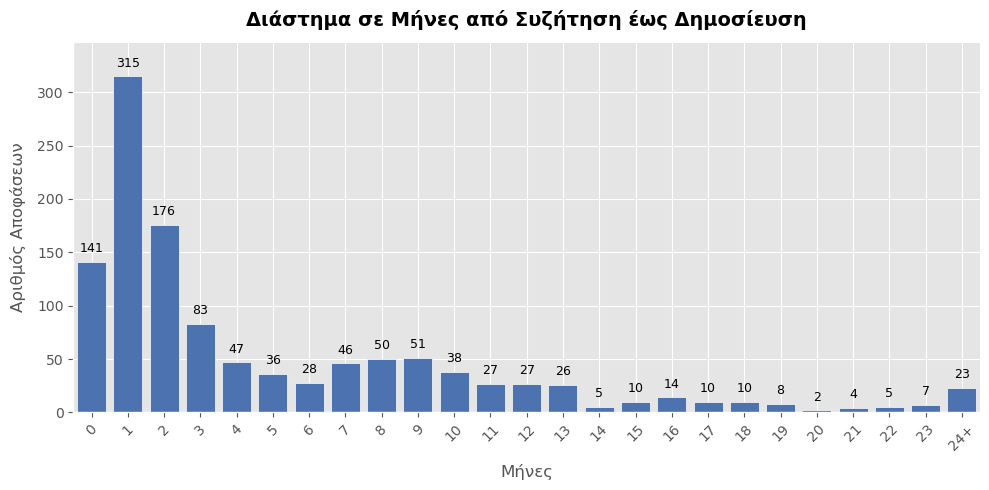

In [101]:
# -----------------------------------------------------------------------------
# Plot 9 – Ιστόγραμμα μήνες lag (συνεδρίαση → δημοσίευση)
# -----------------------------------------------------------------------------
"""
Ερώτημα
-------
Σε πόσους μήνες, συνήθως, δημοσιεύεται μια απόφαση αφού συζητηθεί;
Υπάρχουν πολλά περιστατικά με καθυστέρηση ≥ 2 ετών;

Γιατί column chart τύπου histogram
----------------------------------
• Μετράμε συχνότητα διακριτών τιμών 0, 1, 2 … μηνών·
  οι στήλες κάνουν «τηλεσκόπιο» του καταλόγου.  
• Ένα ενιαίο χρώμα κρατά την προσοχή στον άξονα x.

Ερμηνεία
--------
Η πιο ψηλή μπάρα = ο τυπικός χρόνος αναμονής.  
Η τελευταία μπάρα «24+» μαζεύει όλα τα ακραία περιστατικά·
αν είναι χαμηλή, λίγες υποθέσεις ξεπερνούν τα δύο χρόνια.
"""

month_map = {
    'Ιανουαρίου': 1, 'Φεβρουαρίου': 2, 'Μαρτίου': 3, 'Απριλίου': 4,
    'Μαΐου':      5, 'Ιουνίου':     6, 'Ιουλίου':   7, 'Αυγούστου': 8,
    'Σεπτεμβρίου':9, 'Οκτωβρίου':10, 'Νοεμβρίου':11, 'Δεκεμβρίου':12
}

def parse_gr_date(s):
    if not isinstance(s, str) or not s.strip():
        return pd.NaT
    day_str, mon_str, year_str = s.split()
    day   = int(day_str.rstrip('η'))
    month = month_map.get(mon_str)
    year  = int(year_str)
    return pd.Timestamp(year, month, day)

df['hearing_dt'] = df['hearing_date'].apply(parse_gr_date)
df['pub_dt']     = df['publication_date'].apply(parse_gr_date)
df = df.dropna(subset=['hearing_dt','pub_dt'])

df['delta_months'] = (
    (df['pub_dt'].dt.year  - df['hearing_dt'].dt.year) * 12
  + (df['pub_dt'].dt.month - df['hearing_dt'].dt.month)
)

delta = df['delta_months']
delta = delta[delta >= 0]
delta_capped = delta.clip(upper=24)

bins   = list(range(0,24)) + [24]
labels = [str(i) for i in range(0,24)] + ['24+']
counts = delta_capped.value_counts().reindex(bins, fill_value=0)
counts.index = labels

plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    counts.index, counts.values,
    color='#4C72B0', edgecolor='white', width=0.8
)

maxh = counts.values.max()
for bar in bars:
    h = bar.get_height()
    if h:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            h + maxh*0.02,
            f'{h}',
            ha='center', va='bottom',
            fontsize=9   
        )

ax.set_xticklabels(counts.index, rotation=45, fontsize=10)
ax.set_xlim(-0.5, len(labels)-0.5)
ax.set_ylim(0, maxh * 1.1)

ax.set_title(
    'Διάστημα σε Μήνες από Συζήτηση έως Δημοσίευση',
    fontsize=14, fontweight='bold', pad=12
)
ax.set_xlabel('Μήνες', fontsize=12, labelpad=8)
ax.set_ylabel('Αριθμός Αποφάσεων', fontsize=12, labelpad=8)

for spine in ['top','right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()


C:\Users\perik\AppData\Local\Temp\ipykernel_16164\3676734323.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['delta_label','section_type'])


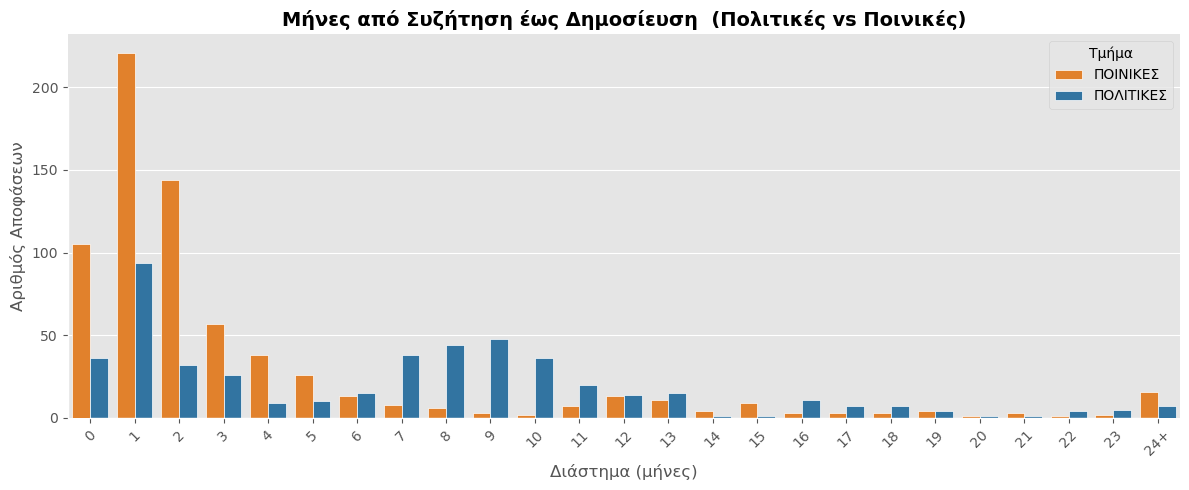

In [102]:
# -----------------------------------------------------------------------------
# Plot 10 – Lag 0-24 μήνες, σύγκριση Πολιτικών vs Ποινικών
# -----------------------------------------------------------------------------
"""
Ερώτημα
-------
Ο χρόνος καθυστέρησης διαφέρει σημαντικά ανάμεσα στα δύο τμήματα;

Γιατί grouped bar
-----------------
• Για κάθε «κάδο» μήνων δείχνω δύο μπάρες δίπλα-δίπλα
  και η διαφορά ύψους φαίνεται αμέσως.  
• Η χρωματική κωδικοποίηση (μπλε/πορτοκαλί) είναι συνεπής
  με όλα τα προηγούμενα plots.

Ερμηνεία
--------
Αν μια μπάρα π.χ. του 6μηνου είναι πολύ ψηλότερη στις Ποινικές,
σημαίνει ότι οι ποινικές αποφάσεις δημοσιεύονται πιο συχνά
έξι μήνες μετά τη συζήτηση σε σχέση με τις πολιτικές.
"""

df = df.copy()
df = df[df['delta_months'].notna()]                    
df = df[df['delta_months'] >= 0]                       
df['delta_clamped'] = df['delta_months'].clip(upper=24)

df['delta_label'] = df['delta_clamped'].astype(int).astype(str)
df.loc[df['delta_clamped'] == 24, 'delta_label'] = '24+'

bin_order = [str(i) for i in range(24)] + ['24+']
df['delta_label'] = pd.Categorical(df['delta_label'], categories=bin_order, ordered=True)

summary = (
    df
    .groupby(['delta_label','section_type'])
    .size()
    .reset_index(name='count')
    .query("section_type in ['ΠΟΛΙΤΙΚΕΣ','ΠΟΙΝΙΚΕΣ']")
)

plt.figure(figsize=(12, 5))
sns.barplot(
    data=summary,
    x='delta_label',
    y='count',
    hue='section_type',
    palette={'ΠΟΛΙΤΙΚΕΣ':'#1f77b4','ΠΟΙΝΙΚΕΣ':'#ff7f0e'},
    edgecolor='white'
)

plt.title("Μήνες από Συζήτηση έως Δημοσίευση  (Πολιτικές vs Ποινικές)", fontsize=14, fontweight='bold')
plt.xlabel("Διάστημα (μήνες)", fontsize=12)
plt.ylabel("Αριθμός Αποφάσεων", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Τμήμα", loc='upper right')

sns.despine(trim=True)

plt.tight_layout()
plt.show()

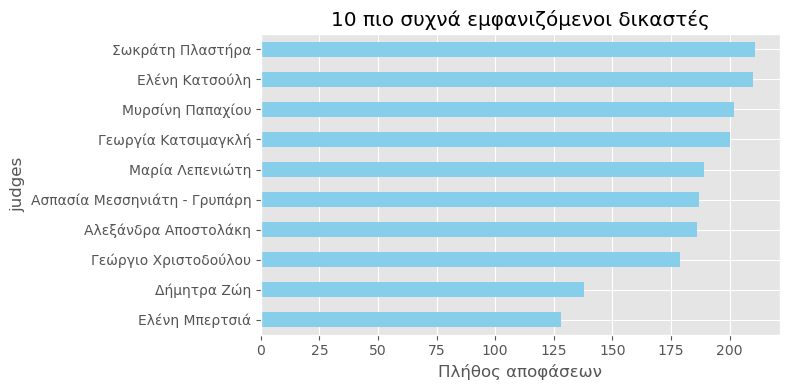

In [103]:
# -----------------------------------------------------------------------------
# Plot 11 – Top-10 δικαστές (global)
# -----------------------------------------------------------------------------
"""
Ερώτημα
-------
Ποιοι δικαστές υπογράφουν τα περισσότερα κείμενα συνολικά;

Γιατί horizontal bar
--------------------
• Τα ονόματα είναι μεγάλα· ο οριζόντιος άξονας αφήνει χώρο.  
• Εύκολο να διαβάσω «μ 1 ↔ μ 2» σε απόσταση εκατοστών.

Ερμηνεία
--------
Η πάνω μπάρα αντιπροσωπεύει τον πιο «παραγωγικό» δικαστή.
Η πτώση ύψους δείχνει πόσο γρήγορα μειώνεται ο όγκος εργασίας
στους επόμενους.
"""

judge_series = (
    df
    .explode('judges')['judges']
    .dropna()
    .str.strip()
)

judge_series = judge_series[~judge_series.str.contains(
    'Αρείου Πάγου', regex=False
)]

judge_counts = judge_series.value_counts().head(10)

plt.figure(figsize=(8,4))
judge_counts.plot(kind='barh', color='skyblue')
plt.title('10 πιο συχνά εμφανιζόμενοι δικαστές')
plt.xlabel('Πλήθος αποφάσεων')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

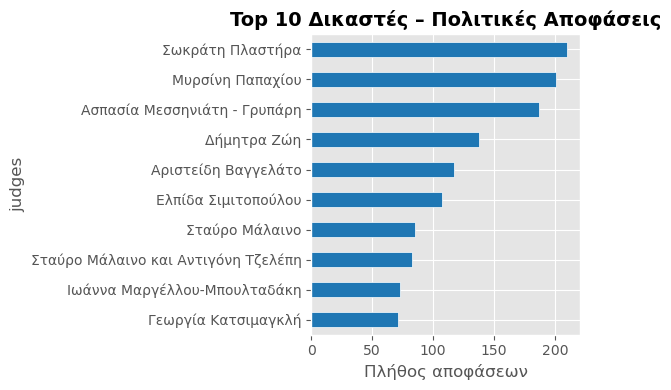

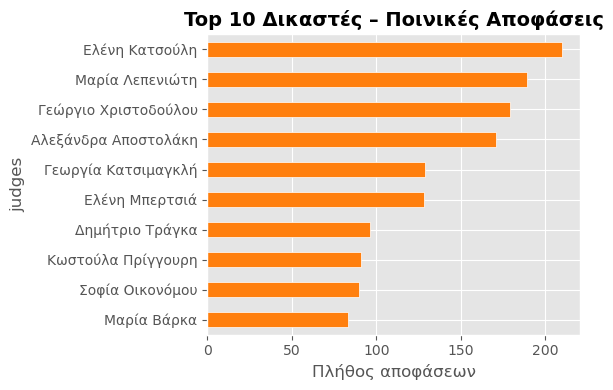

In [104]:
# -----------------------------------------------------------------------------
# Plot 12 – Top-10 δικαστές σε Πολιτικές / Ποινικές
# -----------------------------------------------------------------------------
"""
Ερώτημα
-------
Μέσα σε κάθε τμήμα, αλλάζει η κατάταξη των δικαστών;

Γιατί δύο ξεχωριστά horizontal bars
-----------------------------------
• Κάθε τμήμα διατηρεί το δικό του χρώμα.  
• Ο χρήστης συγκρίνει κατάταξη χωρίς οπτική «επικάλυψη»
  των δύο λιστών.

Ερμηνεία
--------
Εάν ένα όνομα εμφανίζεται και στα δύο γραφήματα, ο ίδιος δικαστής
είναι ενεργός σε περισσότερα από ένα τμήματα· διαφορετικά,
βλέπουμε εξειδίκευση.
"""

def plot_top_judges(df, section_mask, title, color):
    
    s = (
        df[section_mask]
        .explode('judges')['judges']
        .dropna()
        .str.strip()
    )
    
    s = s[~s.str.contains('Αρείου Πάγου', regex=False)]
    
    top10 = s.value_counts().head(10)

    plt.figure(figsize=(6,4))
    top10.plot(
        kind='barh',
        color=color,
        edgecolor='white'
    )
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Πλήθος αποφάσεων')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

pol_mask = df['section_type'].str.contains('ΠΟΛΙΤ', na=False)
plot_top_judges(
    df,
    pol_mask,
    'Top 10 Δικαστές – Πολιτικές Αποφάσεις',
    '#1f77b4'
)

cri_mask = df['section_type'].str.contains('ΠΟΙΝ', na=False)
plot_top_judges(
    df,
    cri_mask,
    'Top 10 Δικαστές – Ποινικές Αποφάσεις',
    '#ff7f0e'
)


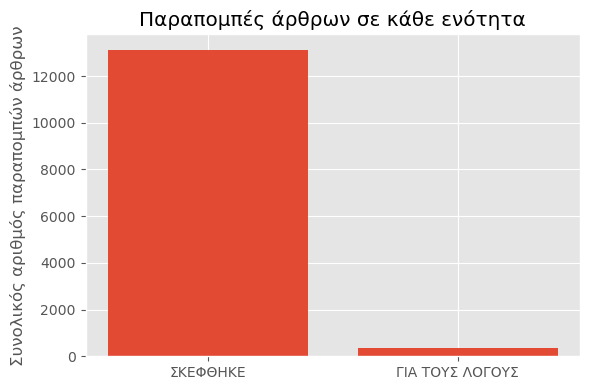

In [105]:
# -----------------------------------------------------------------------------
# Plot 13 – Παραπομπές άρθρων: ΣΚΕΦΘΗΚΕ vs ΓΙΑ ΤΟΥΣ ΛΟΓΟΥΣ (όλα τα τμήματα)
# -----------------------------------------------------------------------------
"""
Ερώτημα
-------
Σε ποιο μέρος της απόφασης (σκεπτικό ή διατακτικό) εμφανίζονται
περισσότερες αναφορές σε άρθρα κωδίκων, συνολικά για όλο το 2024;

Γιατί απλό column chart
-----------------------
• Μόνο δύο κατηγορίες∙ θέλω καθαρή, οπτική σύγκριση ύψους
  χωρίς «οπτικά εφέ».  Η μπάρα που υψώνεται περισσότερο
  αποκαλύπτει ποιο τμήμα του κειμένου είναι πιο “νομο-βαρές”.

Ερμηνεία
--------
Η υψηλότερη μπάρα δείχνει πού φορτώνεται η πλειονότητα των
παραπομπών (συνήθως το ΣΚΕΦΘΗΚΕ).  Οι απόλυτες τιμές (y-axis)
λένε πόσες συνολικές αναφορές έγιναν σε όλο το corpus.
"""

total_skef = 0
total_gia  = 0

for _, row in df.iterrows():
    sect = row.get('section_type') or ""
    
    if 'ΠΟΙΝ' in sect:
        codes = ['ΠΚ', 'Ποινικού Κώδικα', 'ΚΠΔ', 'ΚΠοινΔ', 'Ποινικής Δικονομίας']
    else:
        codes = ['ΑΚ', 'ΚΠολΔ']

    sk_text = row.get('skefthike') or ""
    gi_text = row.get('gia_tous_logous') or ""
    total_skef += len(extract_articles(sk_text, codes))
    total_gia  += len(extract_articles(gi_text, codes))

plt.figure(figsize=(6,4))
plt.bar(['ΣΚΕΦΘΗΚΕ', 'ΓΙΑ ΤΟΥΣ ΛΟΓΟΥΣ'], [total_skef, total_gia])
plt.ylabel('Συνολικός αριθμός παραπομπών άρθρων')
plt.title('Παραπομπές άρθρων σε κάθε ενότητα')
plt.tight_layout()
plt.show()


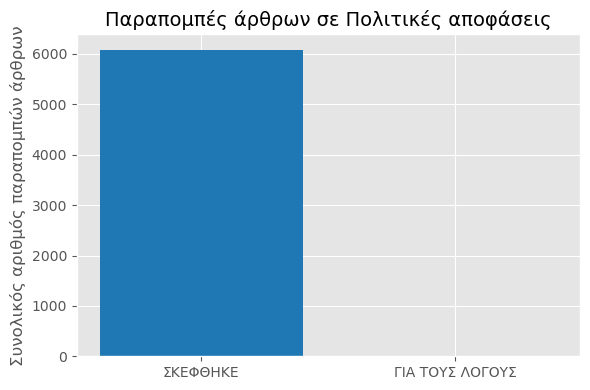

In [106]:
# -----------------------------------------------------------------------------
# Plot 14 – Παραπομπές άρθρων σε Πολιτικές αποφάσεις
# -----------------------------------------------------------------------------
"""
Ερώτημα
-------
Στις καθαρά πολιτικές αποφάσεις, σκεπτικό ή ο λόγος φέρει
περισσότερες αναφορές σε ΑΚ/ΚΠολΔ;

Ερμηνεία
--------
Οι δύο μπάρες (σκούρο & ανοιχτό μπλε) καλύπτουν τον ίδιο άξονα
με το προηγούμενο plot, επιτρέποντας side-by-side σύγκριση.
Αν η μπλε μπάρα εδώ πέφτει, οι πολιτικές αποφάσεις δουλεύουν
με λιγότερη νομοθετική “πυκνότητα”.
"""

pol = df[df['section_type'].str.contains('ΠΟΛΙΤΙΚ', na=False)]

# 2) codes
codes_pol = ['ΑΚ', 'ΚΠολΔ']

# 3) counts
total_sk_pol  = pol['skefthike']\
    .fillna('')\
    .map(lambda t: len(extract_articles(t, codes_pol)))\
    .sum()
total_gtl_pol = pol['gia_tous_logous']\
    .fillna('')\
    .map(lambda t: len(extract_articles(t, codes_pol)))\
    .sum()

# 4) plot
plt.figure(figsize=(6,4))
plt.bar(
    ['ΣΚΕΦΘΗΚΕ','ΓΙΑ ΤΟΥΣ ΛΟΓΟΥΣ'],
    [total_sk_pol, total_gtl_pol],
    color=['#1f77b4','#aec7e8']
)
plt.title('Παραπομπές άρθρων σε Πολιτικές αποφάσεις', fontsize=14)
plt.ylabel('Συνολικός αριθμός παραπομπών άρθρων', fontsize=12)
plt.tight_layout()
plt.show()


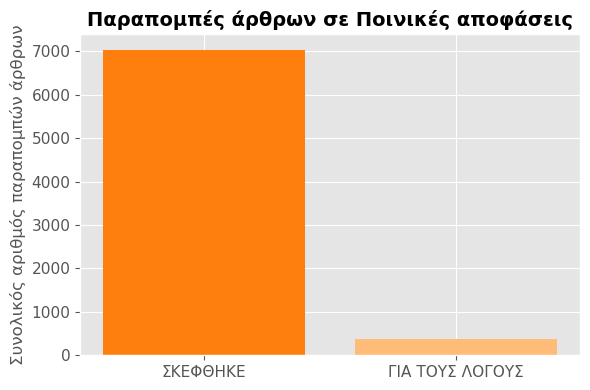

In [107]:
# -----------------------------------------------------------------------------
# Plot 15 – Παραπομπές άρθρων σε Ποινικές αποφάσεις
# -----------------------------------------------------------------------------
"""
Ερώτημα
-------
Αντίστοιχη μέτρηση για τις ποινικές. Φορτώνεται περισσότερο
το σκεπτικό με ΠΚ/ΚΠΔ ή ο λόγος;

Ερμηνεία
--------
Η χρωματική παλέτα παραμένει πορτοκαλί.  Κοιτάω ποια μπάρα
υπερέχει ώστε να ξέρω αν το νομικό “βάρος” της απόφασης
περιγράφεται πριν ή μετά το «ΓΙΑ ΤΟΥΣ ΛΟΓΟΥΣ».
"""

crim = df[df['section_type'].str.contains('ΠΟΙΝ', na=False)]

codes_crim = ['ΠΚ', 'Ποινικού Κώδικα', 'ΚΠΔ', 'ΚΠοινΔ', 'Ποινικής Δικονομίας']

total_sk_crim = (
    crim['skefthike'].fillna('')
         .map(lambda t: len(extract_articles(t, codes_crim)))
         .sum()
)
total_gtl_crim = (
    crim['gia_tous_logous'].fillna('')
         .map(lambda t: len(extract_articles(t, codes_crim)))
         .sum()
)

plt.figure(figsize=(6, 4))
plt.bar(
    ['ΣΚΕΦΘΗΚΕ', 'ΓΙΑ ΤΟΥΣ ΛΟΓΟΥΣ'],
    [total_sk_crim, total_gtl_crim],
    color=['#ff7f0e', '#ffbb78']
)
plt.title('Παραπομπές άρθρων σε Ποινικές αποφάσεις', fontsize=14, fontweight='bold')
plt.ylabel('Συνολικός αριθμός παραπομπών άρθρων', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()


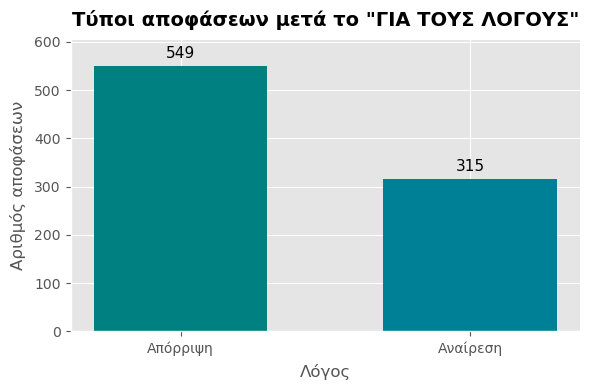

In [108]:
# -----------------------------------------------------------------------------
# Plot 16 – Τύποι καταλήξεων (Απόρριψη vs Αναίρεση)
# -----------------------------------------------------------------------------
"""
Ερώτημα
-------
Τι «κατάληξη» συναντάται συχνότερα στο block ΓΙΑ ΤΟΥΣ ΛΟΓΟΥΣ:
η φράση «Απορρίπτει» ή «Αναιρεί»;

Γιατί διπλή μπάρα
-----------------
• Οι αποφάσεις κατατάσσονται σε δύο βασικά outcomes – αρκούν
  δύο μπάρες ώστε η πλειοψηφία να ξεχωρίσει άμεσα.

Ερμηνεία
--------
Η μπάρα με το μεγαλύτερο label/ύψος αποκαλύπτει ποια ενέργεια
(απόρριψη ή αναίρεση) κυριαρχεί στο 2024.
"""

counts = (
    verbs
    .value_counts()
    .reindex(['Απορρίπτει','Αναιρεί'], fill_value=0)
    .rename(index={
        'Απορρίπτει': 'Απόρριψη',
        'Αναιρεί':    'Αναίρεση'
    })
)

fig, ax = plt.subplots(figsize=(6,4))
bars = ax.bar(
    counts.index,
    counts.values,
    color=['#008080','#008097'],    
    width=0.6
)

ax.bar_label(bars, labels=counts.values, padding=4, fontsize=11)

ax.set_title('Τύποι αποφάσεων μετά το "ΓΙΑ ΤΟΥΣ ΛΟΓΟΥΣ"', 
             fontsize=14, fontweight='bold', pad=10)
ax.set_xlabel('Λόγος', fontsize=12, labelpad=6)
ax.set_ylabel('Αριθμός αποφάσεων', fontsize=12, labelpad=6)

for spine in ['top','right']:
    ax.spines[spine].set_visible(False)
ax.set_ylim(0, counts.values.max() * 1.1)

plt.tight_layout()
plt.show()

C:\Users\perik\AppData\Local\Temp\ipykernel_16164\3212305970.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(bin_counts.index, rotation=45, ha='right', fontsize=10)


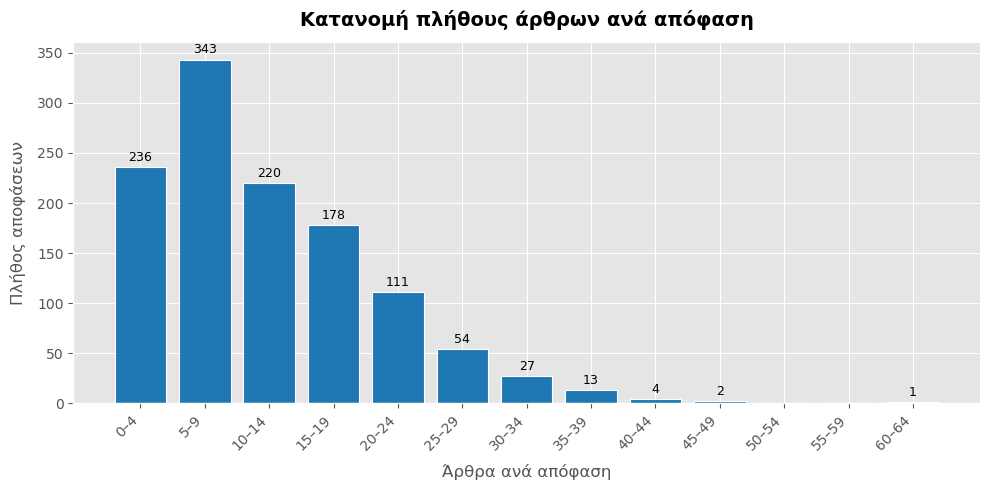

In [109]:
# -----------------------------------------------------------------------------
# Plot 17 – Πλήθος αναφορών κωδικών ανά απόφαση (histogram-style)
# -----------------------------------------------------------------------------
"""
Ερώτημα
-------
Πόσες διαφορετικές νομοθετικές παραπομπές περιέχει μια
«τυπική» απόφαση;  Χωρίζω σε κάδους 0-4, 5-9, … 20-24, 24+.

Γιατί column histogram
----------------------
• Θέλω κατανομή συχνοτήτων σε διακριτά διαστήματα.  Οι μπάρες
  αποκαλύπτουν αμέσως αν οι περισσότερες αποφάσεις είναι
  ‘νομοθετικά ελαφριές’ (0-4) ή ‘βαριές’ (>20).

Ερμηνεία
--------
Η ψηλότερη στήλη = modal class· εκεί βρίσκεται ο
«μέσος όρος» άρθρων ανά απόφαση.
"""

def parse_list(cell):
    if isinstance(cell, list):
        return cell
    if isinstance(cell, str):
        try:
            lst = ast.literal_eval(cell)
            if isinstance(lst, list):
                return lst
        except Exception:
            pass
    return []

df['total_articles'] = (
    df['penal_code_articles'].apply(parse_list).map(len)
  + df['penal_proc_articles'].apply(parse_list).map(len)
  + df['civil_code_articles'].apply(parse_list).map(len)
  + df['civil_proc_code_articles'].apply(parse_list).map(len)
)

max_art = int(df['total_articles'].max())
bins = list(range(0, max_art + 6, 5))      
labels = [f"{bins[i]}–{bins[i+1]-1}" for i in range(len(bins)-1)]
df['art_bin'] = pd.cut(df['total_articles'], bins=bins, right=False, labels=labels)
bin_counts = df['art_bin'].value_counts().sort_index()

plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    bin_counts.index, 
    bin_counts.values,
    color='#1f77b4',       
    edgecolor='white',
    linewidth=0.8,
    width=0.8
)

for bar in bars:
    h = bar.get_height()
    if h > 0:
        ax.text(
            bar.get_x() + bar.get_width()/2, 
            h + bin_counts.values.max()*0.01,
            f"{h}", 
            ha='center', 
            va='bottom', 
            fontsize=9
        )

ax.set_title('Κατανομή πλήθους άρθρων ανά απόφαση', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Άρθρα ανά απόφαση', fontsize=12, labelpad=8)
ax.set_ylabel('Πλήθος αποφάσεων', fontsize=12, labelpad=8)

ax.set_xticklabels(bin_counts.index, rotation=45, ha='right', fontsize=10)
for spine in ['top','right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()


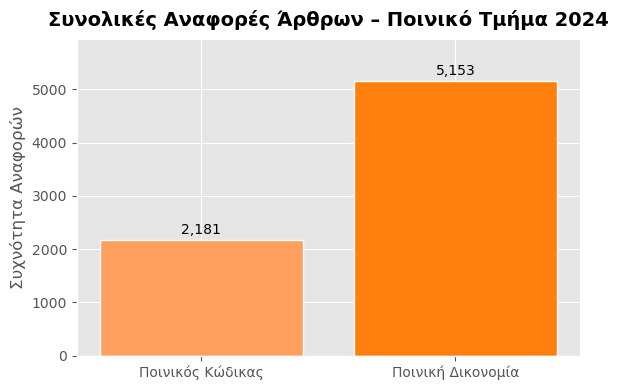

In [110]:
# -----------------------------------------------------------------------------
# Plot 18 – Σύνολο αναφορών ΠΚ vs ΚΠΔ (μόνο Ποινικό τμήμα)
# -----------------------------------------------------------------------------
"""
Ερώτημα
-------
Στις ποινικές αποφάσεις ποιες αναφορές υπερτερούν:
άρθρα Ποινικού Κώδικα ή Κώδικα Ποινικής Δικονομίας;

Ερμηνεία
--------
Δύο πορτοκαλί μπάρες· η ψηλότερη δείχνει ποια συλλογή άρθρων
χρησιμοποιείται πιο εντατικά στο ποινικό corpus.
"""

df_poin = df[df['section_type'].str.contains('ΠΟΙΝ', na=False)]

penal_code_total = df_poin['penal_code_articles'].apply(parse_list).map(len).sum()
penal_proc_total = df_poin['penal_proc_articles'].apply(parse_list).map(len).sum()

plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(6, 4))

labels = ['Ποινικός Κώδικας', 'Ποινική Δικονομία']
values = [penal_code_total, penal_proc_total]
colors = ['#ff9f5e', '#ff7f0e']  

bars = ax.bar(labels, values, color=colors, edgecolor='white', linewidth=1)

for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + max(values)*0.01,
        f"{h:,}",
        ha='center', va='bottom',
        fontsize=10
    )

ax.set_title(
    'Συνολικές Αναφορές Άρθρων – Ποινικό Τμήμα 2024',
    fontsize=14, fontweight='bold', pad=10
)
ax.set_ylabel('Συχνότητα Αναφορών', fontsize=12)
ax.set_ylim(0, max(values) * 1.15)

for spine in ['top','right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()


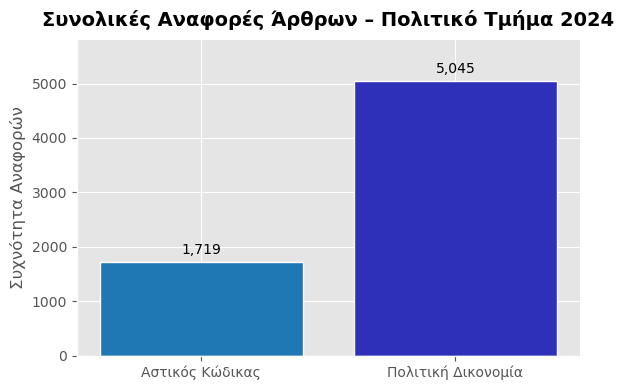

In [111]:
# -----------------------------------------------------------------------------
# Plot 19 – Σύνολο αναφορών ΑΚ vs ΚΠολΔ (μόνο Πολιτικό τμήμα)
# -----------------------------------------------------------------------------
"""
Ερώτημα
-------
Για τις πολιτικές αποφάσεις, ποιος κώδικας κυριαρχεί σε αναφορές:
Αστικός ή Πολιτικής Δικονομίας;

Ερμηνεία
--------
Αν η μπλε μπάρα «Αστικός Κώδικας» είναι ψηλότερη, οι αποφάσεις
ανατρέχουν πιο συχνά σε ουσιαστικές διατάξεις παρά σε δικονομικές.
"""

df_polit = df[df['section_type'].str.contains('ΠΟΛΙΤ', na=False)]

civil_code_total = df_polit['civil_code_articles']     .apply(parse_list).map(len).sum()
civil_proc_total = df_polit['civil_proc_code_articles'].apply(parse_list).map(len).sum()

plt.style.use('ggplot')

labels = ['Αστικός Κώδικας', 'Πολιτική Δικονομία']
values = [civil_code_total, civil_proc_total]
colors = ['#1f77b4', '#2f30b9']

fig, ax = plt.subplots(figsize=(6,4))
bars = ax.bar(labels, values, color=colors, edgecolor='white', linewidth=1)

for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + max(values)*0.02,
        f"{h:,}",
        ha='center', va='bottom',
        fontsize=10
    )

ax.set_title(
    'Συνολικές Αναφορές Άρθρων – Πολιτικό Τμήμα 2024',
    fontsize=14, fontweight='bold', pad=10
)
ax.set_ylabel('Συχνότητα Αναφορών', fontsize=12)
ax.set_ylim(0, max(values)*1.15)

for spine in ['top','right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

In [112]:
# -----------------------------------------------------------------------------
# Plot N – Top-10 άρθρα ανά κώδικα (4 ξεχωριστά γραφήματα)
# -----------------------------------------------------------------------------
"""
Ερώτημα
-------
Ποια συγκεκριμένα άρθρα είναι τα πιο συχνά επικαλούμενα σε:
   1. ΠΚ,   2. ΚΠΔ,   3. ΑΚ,   4. ΚΠολΔ;

Γιατί 4 οριζόντια bar charts
----------------------------
• Κάθε κώδικας έχει το δικό του top-10· οριζόντιες μπάρες
  επιτρέπουν τα labels «άρθρο 464» κ.λπ. να χωρέσουν καθαρά.  
• Ξεχωριστά γραφήματα κρατούν την παλέτα συνεπή και αποφεύγουν
  οπτική συμφόρηση.

Ερμηνεία
--------
Ο αναγνώστης βλέπει ποιο άρθρο βρίσκεται στην κορυφή – αυτό
μπορεί να υποδεικνύει καυτά νομικά ζητήματα για το 2024,
π.χ. αν κυριαρχεί το «άρθρο 361 ΠΚ» (δυσφήμηση) ή το
«άρθρο 281 ΑΚ» (κατάχρηση δικαιώματος).
"""

import ast
def parse_list(cell):
    if isinstance(cell, list):
        return cell
    if isinstance(cell, str):
        try:
            lst = ast.literal_eval(cell)
            if isinstance(lst, list):
                return lst
        except:
            pass
    return []

def strip_para(ref: str) -> str:
    m = re.match(r"άρθρο\s+(\d+)", ref, flags=re.IGNORECASE)
    return f"άρθρο {m.group(1)}" if m else ref

def plot_top10(series, title, color):
    counts = (series
            .explode()
            .dropna()
            .map(strip_para)
            .value_counts()
            .head(10))
    fig, ax = plt.subplots(figsize=(6,4))
    counts.plot(kind='barh', ax=ax, color=color)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Αριθμός εμφανίσεων', fontsize=12)
    ax.invert_yaxis()
    for spine in ['top','right']:
        ax.spines[spine].set_visible(False)
    plt.tight_layout()

df_poin = df[df['section_type'].str.contains('ΠΟΙΝ', na=False)]
df_polit = df[df['section_type'].str.contains('ΠΟΛΙΤ', na=False)]

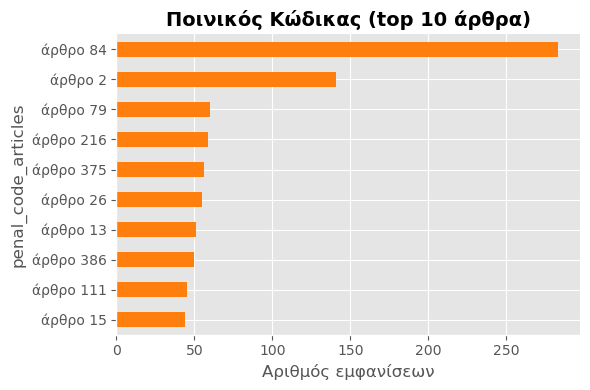

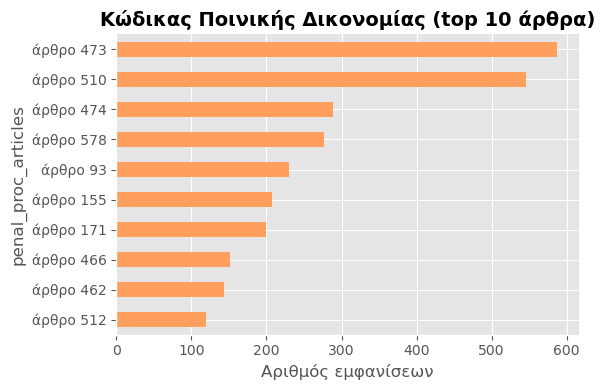

In [113]:
plot_top10(
    df_poin['penal_code_articles'].apply(parse_list),
    title='Ποινικός Κώδικας (top 10 άρθρα)',
    color='#ff7f0e'
)

# 2) Κώδικας Ποινικής Δικονομίας
plot_top10(
    df_poin['penal_proc_articles'].apply(parse_list),
    title='Κώδικας Ποινικής Δικονομίας (top 10 άρθρα)',
    color='#ff9f5e'
)

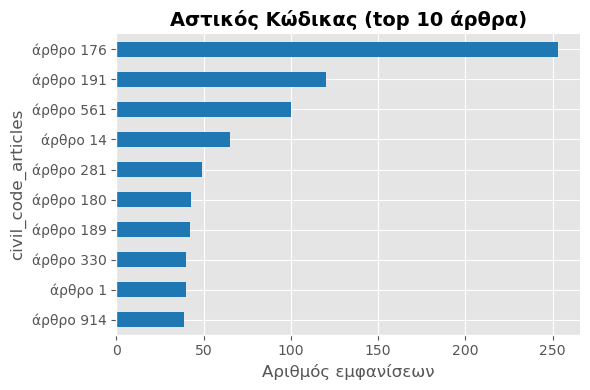

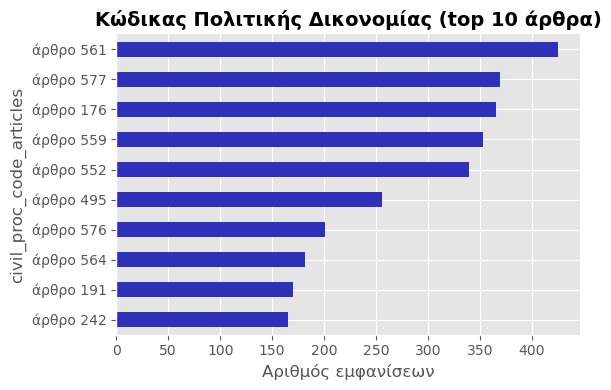

In [114]:
# 3) Αστικός Κώδικας
plot_top10(
    df_polit['civil_code_articles'].apply(parse_list),
    title='Αστικός Κώδικας (top 10 άρθρα)',
    color='#1f77b4'
)

# 4) Κώδικας Πολιτικής Δικονομίας
plot_top10(
    df_polit['civil_proc_code_articles'].apply(parse_list),
    title='Κώδικας Πολιτικής Δικονομίας (top 10 άρθρα)',
    color='#2f30b9'
)
